<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Redes Neurais Artificiais, Deep Learning e Algoritmos Genéticos</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
  <img src="https://img.shields.io/badge/PyTorch-EE4C2C?style=for-the-badge&logo=pytorch&logoColor=white"/>
</div>


## Instalação das dependências

| Biblioteca | Uso |
|------------|-----|
| `numpy` | Manipulação de arrays e geração de dados |
| `matplotlib` | Visualizações |
| `scikit-learn` | Métricas de classificação |
| `torch` | Tensores, Conv2d e otimizadores |
| `torchvision` | Datasets (MNIST, CIFAR-10) e transformações |

In [ ]:
#%pip install -r requirements.txt --quiet

## Aula 07c: Redes Neurais Convolucionais com Datasets Reais

As arquiteturas das aulas anteriores (FNN, RNN, LSTM, GRU) processam **vetores**: sequências de números. Para imagens, uma FNN precisaria tratar cada pixel como uma feature independente: uma imagem 32×32 em RGB geraria **3 072 features** por entrada. Além disso, a FNN não capturaria a **estrutura espacial**: o fato de que pixels vizinhos formam padrões coerentes (bordas, texturas, formas).

A **CNN** resolve isso com a operação de **convolução**: um filtro pequeno percorre a imagem inteira, detectando o mesmo padrão em qualquer posição. Isso garante:

- **Compartilhamento de pesos:** o mesmo filtro detecta uma borda tanto no canto superior quanto no inferior da imagem
- **Invariância translacional:** o modelo reconhece um gato independentemente de onde ele esteja na imagem
- **Hierarquia de features:** camadas iniciais detectam bordas → camadas intermediárias detectam texturas → camadas profundas detectam objetos

> **Nesta aula** implementaremos CNNs para dois datasets de imagens de complexidade crescente: **MNIST** (dígitos manuscritos) e **CIFAR-10** (objetos coloridos).

## 1. Por que CNN? Limitações da FNN para Imagens

Uma FNN com `Flatten` perde completamente a informação espacial:

```
Imagem 28×28 → Flatten → vetor de 784 → Linear(784, 128) → ...
```

O pixel `[5, 10]` e o pixel `[5, 11]` (vizinhos) são tratados como features completamente independentes. A FNN não sabe que eles estão lado a lado.

**Comparação de parâmetros para uma imagem 28×28 (MNIST):**

| Abordagem | Primeira camada | Parâmetros |
|-----------|----------------|------------|
| FNN (Flatten → 128) | `Linear(784, 128)` | 100 480 |
| CNN (3×3, 32 filtros) | `Conv2d(1, 32, 3)` | **320** |

A convolução usa **99,7% menos parâmetros** na primeira camada, e ainda captura estrutura espacial.

## 2. Arquitetura CNN

### 2.1 Operação de Convolução

Um filtro (kernel) de tamanho $F \times F$ desliza sobre a imagem com passo (*stride*) $S$ e padding $P$. O tamanho da saída (*feature map*) é:

$$W_{out} = \left\lfloor \frac{W_{in} - F + 2P}{S} \right\rfloor + 1$$

**Exemplo:** imagem 28×28, filtro 3×3, stride=1, padding=0:

$$W_{out} = \frac{28 - 3 + 0}{1} + 1 = 26$$

### 2.2 Componentes Principais

| Camada | Função |
|--------|--------|
| `Conv2d(in, out, kernel)` | Aplica `out` filtros de tamanho `kernel×kernel` |
| `ReLU` | Não-linearidade: igual às outras arquiteturas |
| `MaxPool2d(k)` | Reduz dimensão por fator `k`, mantém valor máximo local |
| `BatchNorm2d` | Normaliza as ativações: acelera convergência, regulariza |
| `Dropout` | Regularização: desativa neurônios aleatoriamente |
| `Flatten` | Transforma o tensor 2D em vetor para a cabeça classificadora |
| `Linear` | Cabeça classificadora totalmente conectada |

### 2.3 Fluxo de uma CNN típica

```
Entrada (B, C, H, W)
  ↓ Conv2d + ReLU
(B, 32, H', W')      ← feature maps com padrões de baixo nível
  ↓ MaxPool2d
(B, 32, H'/2, W'/2)
  ↓ Conv2d + ReLU
(B, 64, H'', W'')    ← padrões de nível intermediário
  ↓ MaxPool2d
  ↓ Flatten
(B, 64 × H'' × W'')
  ↓ Linear + ReLU
  ↓ Linear
(B, n_classes)       ← logits finais
```

## 3. Bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}  |  PyTorch {torch.__version__}")

Dispositivo: cpu  |  PyTorch 2.11.0


## 4. Caso 1: Reconhecimento de Dígitos (MNIST)

**Dataset:** [MNIST](http://yann.lecun.com/exdb/mnist/): 70 000 imagens de dígitos manuscritos (0–9), 28×28 pixels, escala de cinza.

**Objetivo:** classificar o dígito correto (10 classes) a partir da imagem.

| Característica | Valor |
|---|---|
| Imagens de treino | 60 000 |
| Imagens de teste | 10 000 |
| Resolução | 28 × 28 pixels |
| Canais | 1 (escala de cinza) |
| Classes | 10 (dígitos 0–9) |

### 4.1 Carregamento e Visualização

Treino : 60,000 imagens  |  Teste: 10,000 imagens
Shape de uma imagem: torch.Size([1, 28, 28])


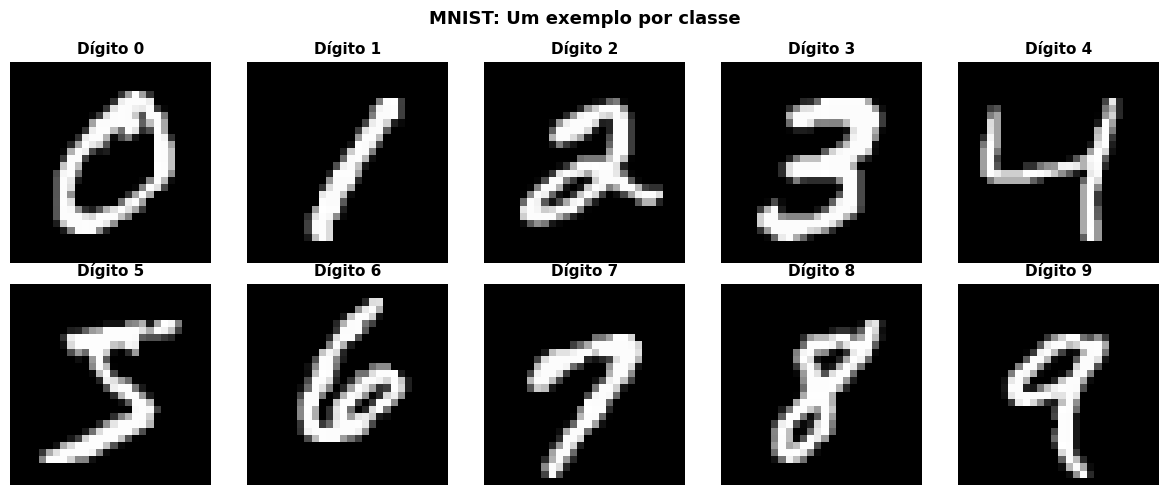

In [2]:
# Transformação: tensor normalizado com média=0.1307 e desvio=0.3081 (estatísticas do MNIST)
transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

ds_tr = datasets.MNIST("data/mnist", train=True,  download=True, transform=transform_mnist)
ds_te = datasets.MNIST("data/mnist", train=False, download=True, transform=transform_mnist)

loader_tr_m = DataLoader(ds_tr, batch_size=128, shuffle=True,  num_workers=0)
loader_te_m = DataLoader(ds_te, batch_size=256, shuffle=False, num_workers=0)

print(f"Treino : {len(ds_tr):,} imagens  |  Teste: {len(ds_te):,} imagens")
print(f"Shape de uma imagem: {ds_tr[0][0].shape}")   # (1, 28, 28)

# Visualiza 10 exemplos (um por classe)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
contagem = {}
for img, label in ds_tr:
    if label not in contagem:
        contagem[label] = img
    if len(contagem) == 10:
        break

for ax, (label, img) in zip(axes.ravel(), sorted(contagem.items())):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Dígito {label}", fontsize=11, fontweight="bold")
    ax.axis("off")

plt.suptitle("MNIST: Um exemplo por classe", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.2 Modelo CNN para MNIST

Arquitetura com dois blocos convolucionais seguidos de uma cabeça classificadora totalmente conectada.

**Dimensões ao longo da rede (entrada: 1×28×28):**

| Camada | Saída |
|--------|-------|
| Conv2d(1→32, 3×3) + ReLU | 32×26×26 |
| MaxPool2d(2) | 32×13×13 |
| Conv2d(32→64, 3×3) + ReLU | 64×11×11 |
| MaxPool2d(2) | 64×5×5 |
| Flatten | 1 600 |
| Linear(1600→128) + ReLU | 128 |
| Linear(128→10) | 10 logits |

In [3]:
class CNN_MNIST(nn.Module):
    """
    CNN para classificação de dígitos (MNIST).

    Entrada : (batch, 1, 28, 28)
    Saída   : (batch, 10) : logits para cada dígito
    """
    def __init__(self, dropout=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3),   # → (B, 32, 26, 26)
            nn.ReLU(),
            nn.MaxPool2d(2),                   # → (B, 32, 13, 13)
            nn.Conv2d(32, 64, kernel_size=3),  # → (B, 64, 11, 11)
            nn.ReLU(),
            nn.MaxPool2d(2),                   # → (B, 64, 5, 5)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 5 * 5, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

modelo_mnist = CNN_MNIST().to(device)
total_params = sum(p.numel() for p in modelo_mnist.parameters() if p.requires_grad)
print(f"Parâmetros treináveis: {total_params:,}")
print(modelo_mnist)

Parâmetros treináveis: 225,034
CNN_MNIST(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1600, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


### 4.3 Treinamento

| Hiperparâmetro | Valor |
|----------------|-------|
| Épocas         | 10    |
| Learning rate  | 1e-3  |
| Batch size     | 128   |
| Otimizador     | Adam  |
| Perda          | CrossEntropyLoss |
| Dropout        | 0.25  |

In [4]:
EPOCHS_M = 10
LR_M     = 1e-3

criterio_m   = nn.CrossEntropyLoss()
otimizador_m = optim.Adam(modelo_mnist.parameters(), lr=LR_M)

hist_loss_tr_m, hist_loss_te_m = [], []
hist_acc_tr_m,  hist_acc_te_m  = [], []

for epoca in range(1, EPOCHS_M + 1):
    modelo_mnist.train()
    loss_soma, acertos, total = 0.0, 0, 0
    for xb, yb in loader_tr_m:
        xb, yb = xb.to(device), yb.to(device)
        logits = modelo_mnist(xb)
        loss   = criterio_m(logits, yb)
        otimizador_m.zero_grad()
        loss.backward()
        otimizador_m.step()
        loss_soma += loss.item()
        acertos   += (logits.argmax(1) == yb).sum().item()
        total     += len(yb)

    modelo_mnist.eval()
    loss_te_soma, ac_te, tot_te = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader_te_m:
            xb, yb = xb.to(device), yb.to(device)
            logits = modelo_mnist(xb)
            loss_te_soma += criterio_m(logits, yb).item()
            ac_te        += (logits.argmax(1) == yb).sum().item()
            tot_te       += len(yb)

    hist_loss_tr_m.append(loss_soma / len(loader_tr_m))
    hist_loss_te_m.append(loss_te_soma / len(loader_te_m))
    hist_acc_tr_m.append(acertos / total)
    hist_acc_te_m.append(ac_te / tot_te)

    print(f"Época {epoca:2d} | Loss: {hist_loss_tr_m[-1]:.4f}/{hist_loss_te_m[-1]:.4f} "
          f"| Acc: {acertos/total:.4f}/{ac_te/tot_te:.4f}")

Época  1 | Loss: 0.2092/0.0550 | Acc: 0.9368/0.9815
Época  2 | Loss: 0.0597/0.0309 | Acc: 0.9815/0.9899
Época  3 | Loss: 0.0417/0.0348 | Acc: 0.9873/0.9882
Época  4 | Loss: 0.0336/0.0324 | Acc: 0.9896/0.9892
Época  5 | Loss: 0.0263/0.0297 | Acc: 0.9916/0.9895
Época  6 | Loss: 0.0226/0.0277 | Acc: 0.9928/0.9912
Época  7 | Loss: 0.0191/0.0290 | Acc: 0.9940/0.9910
Época  8 | Loss: 0.0164/0.0237 | Acc: 0.9949/0.9915
Época  9 | Loss: 0.0147/0.0262 | Acc: 0.9949/0.9924
Época 10 | Loss: 0.0133/0.0325 | Acc: 0.9955/0.9904


### 4.4 Resultados

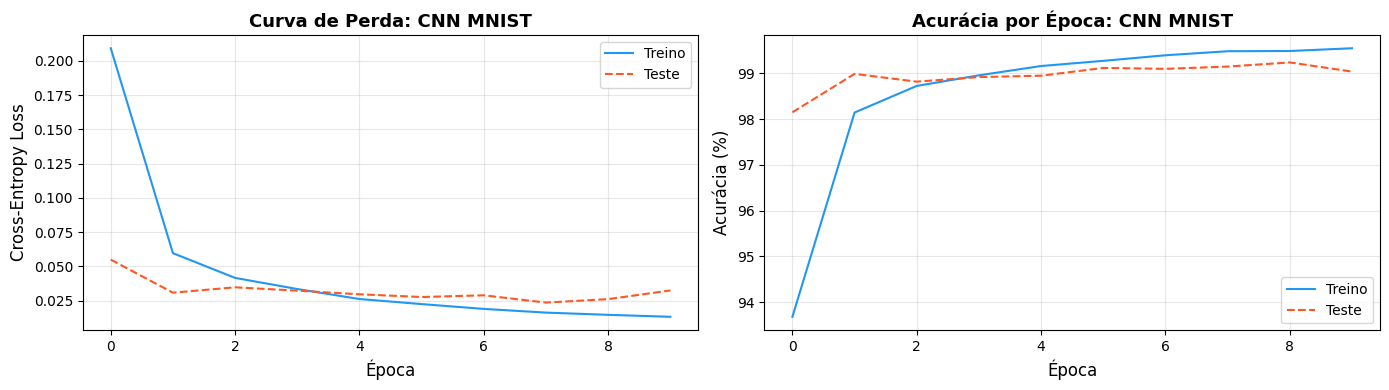


Acurácia final no teste: 99.04%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(hist_loss_tr_m, label="Treino", color="#2196F3", lw=1.5)
ax.plot(hist_loss_te_m, label="Teste",  color="#FF5722", lw=1.5, linestyle="--")
ax.set_xlabel("Época", fontsize=12); ax.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax.set_title("Curva de Perda: CNN MNIST", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot([a*100 for a in hist_acc_tr_m], label="Treino", color="#2196F3", lw=1.5)
ax.plot([a*100 for a in hist_acc_te_m], label="Teste",  color="#FF5722", lw=1.5, linestyle="--")
ax.set_xlabel("Época", fontsize=12); ax.set_ylabel("Acurácia (%)", fontsize=12)
ax.set_title("Acurácia por Época: CNN MNIST", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

acc_mnist = hist_acc_te_m[-1]
print(f"\nAcurácia final no teste: {acc_mnist*100:.2f}%")

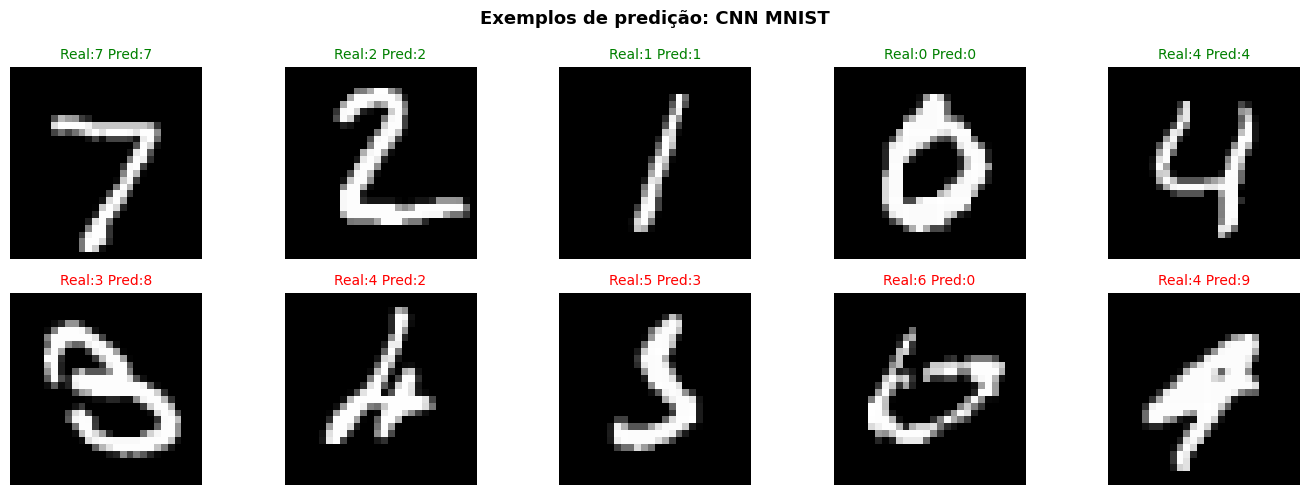

In [6]:
# Visualiza predições corretas e incorretas
modelo_mnist.eval()
imagens_erros, imagens_certas = [], []

with torch.no_grad():
    for xb, yb in loader_te_m:
        xb, yb = xb.to(device), yb.to(device)
        preds = modelo_mnist(xb).argmax(1)
        for img, real, pred in zip(xb, yb, preds):
            if real != pred and len(imagens_erros) < 5:
                imagens_erros.append((img.cpu(), real.item(), pred.item()))
            if real == pred and len(imagens_certas) < 5:
                imagens_certas.append((img.cpu(), real.item(), pred.item()))
        if len(imagens_erros) == 5 and len(imagens_certas) == 5:
            break

fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for i, (img, real, pred) in enumerate(imagens_certas):
    axes[0, i].imshow(img.squeeze(), cmap="gray")
    axes[0, i].set_title(f"Real:{real} Pred:{pred}", color="green", fontsize=10)
    axes[0, i].axis("off")
for i, (img, real, pred) in enumerate(imagens_erros):
    axes[1, i].imshow(img.squeeze(), cmap="gray")
    axes[1, i].set_title(f"Real:{real} Pred:{pred}", color="red", fontsize=10)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Corretas", fontsize=11, fontweight="bold", color="green")
axes[1, 0].set_ylabel("Erradas",  fontsize=11, fontweight="bold", color="red")
plt.suptitle("Exemplos de predição: CNN MNIST", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
import os
os.makedirs("models", exist_ok=True)
torch.save({"model_state_dict": modelo_mnist.state_dict(),
            "accuracy_test":    acc_mnist,
            "n_classes":        10},
           "models/cnn_mnist.pth")

print("Checkpoint salvo em models/cnn_mnist.pth")

Checkpoint salvo em models/cnn_mnist.pth


## 5. Caso 2: Classificação de Objetos (CIFAR-10)

**Dataset:** [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html): 60 000 imagens coloridas de 10 categorias, 32×32 pixels, RGB.

**Objetivo:** classificar corretamente a categoria do objeto na imagem.

| Característica | MNIST | CIFAR-10 |
|---|---|---|
| Imagens de treino | 60 000 | 50 000 |
| Imagens de teste | 10 000 | 10 000 |
| Resolução | 28×28 | **32×32** |
| Canais | 1 (cinza) | **3 (RGB)** |
| Classes | 10 dígitos | **10 objetos** |
| Dificuldade | Baixa | **Alta** |

As classes do CIFAR-10 são: `airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`.

> CIFAR-10 é significativamente mais desafiador que MNIST: objetos têm variações de pose, iluminação e fundo. Usaremos **data augmentation** e **Batch Normalization** para melhorar a generalização.

### 5.1 Carregamento e Visualização

100.0%
/Users/mitoura/Desktop/FIAP/Materiais/02_RedesNeurais/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Treino : 50,000 imagens  |  Teste: 10,000 imagens
Shape de uma imagem: torch.Size([3, 32, 32])


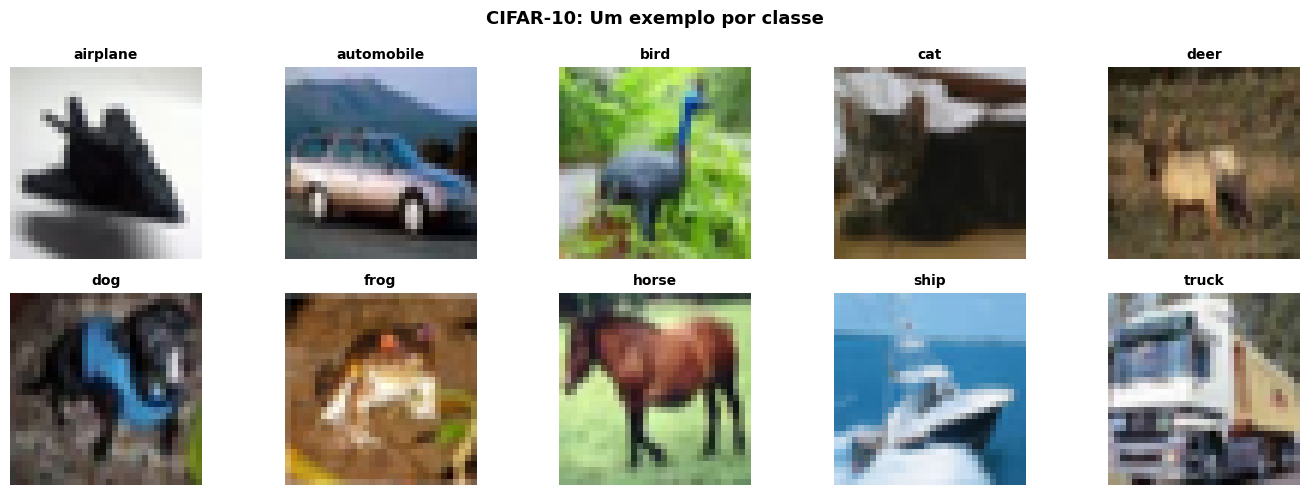

In [8]:
CLASSES_CIFAR = ["airplane","automobile","bird","cat","deer",
                 "dog","frog","horse","ship","truck"]

# Data augmentation no treino; apenas normalização no teste
transform_tr_c = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),   # média por canal RGB
                         (0.2023, 0.1994, 0.2010)),
])
transform_te_c = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

ds_tr_c = datasets.CIFAR10("data/cifar10", train=True,  download=True, transform=transform_tr_c)
ds_te_c = datasets.CIFAR10("data/cifar10", train=False, download=True, transform=transform_te_c)

loader_tr_c = DataLoader(ds_tr_c, batch_size=128, shuffle=True,  num_workers=0)
loader_te_c = DataLoader(ds_te_c, batch_size=256, shuffle=False, num_workers=0)

print(f"Treino : {len(ds_tr_c):,} imagens  |  Teste: {len(ds_te_c):,} imagens")
print(f"Shape de uma imagem: {ds_tr_c[0][0].shape}")   # (3, 32, 32)

# Visualiza exemplos por classe
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
contagem_c = {}
# Usa dataset sem augmentation para visualização mais limpa
ds_vis = datasets.CIFAR10("data/cifar10", train=True, download=False,
                           transform=transforms.ToTensor())
for img, label in ds_vis:
    if label not in contagem_c:
        contagem_c[label] = img
    if len(contagem_c) == 10:
        break

for ax, (label, img) in zip(axes.ravel(), sorted(contagem_c.items())):
    ax.imshow(img.permute(1, 2, 0).numpy())   # (C,H,W) → (H,W,C)
    ax.set_title(CLASSES_CIFAR[label], fontsize=10, fontweight="bold")
    ax.axis("off")

plt.suptitle("CIFAR-10: Um exemplo por classe", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 5.2 Modelo CNN para CIFAR-10

Arquitetura mais profunda com **Batch Normalization** e três blocos convolucionais.

**Dimensões ao longo da rede (entrada: 3×32×32):**

| Bloco | Operação | Saída |
|-------|----------|-------|
| Bloco 1 | Conv2d(3→32, 3, p=1) + BN + ReLU + MaxPool | 32×16×16 |
| Bloco 2 | Conv2d(32→64, 3, p=1) + BN + ReLU + MaxPool | 64×8×8 |
| Bloco 3 | Conv2d(64→128, 3, p=1) + BN + ReLU + MaxPool | 128×4×4 |
| Cabeça | Flatten → Linear(2048→512) → Linear(512→10) | 10 logits |

> **padding=1** mantém a dimensão espacial após a convolução 3×3: $(32 - 3 + 2) / 1 + 1 = 32$. O MaxPool2d(2) reduz pela metade.

In [9]:
class CNN_CIFAR10(nn.Module):
    """
    CNN com BatchNorm para classificação CIFAR-10.

    Entrada : (batch, 3, 32, 32)
    Saída   : (batch, 10) : logits para cada classe
    """
    def __init__(self, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            # Bloco 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # → (B, 32, 32, 32)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                               # → (B, 32, 16, 16)
            # Bloco 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # → (B, 64, 16, 16)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                               # → (B, 64, 8, 8)
            # Bloco 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # → (B, 128, 8, 8)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                               # → (B, 128, 4, 4)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                       # → 128 * 4 * 4 = 2048
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

modelo_cifar = CNN_CIFAR10().to(device)
total_cifar  = sum(p.numel() for p in modelo_cifar.parameters() if p.requires_grad)
print(f"Parâmetros treináveis: {total_cifar:,}")
print(modelo_cifar)

Parâmetros treináveis: 1,147,914
CNN_CIFAR10(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=512, bias=Tr

### 5.3 Treinamento

| Hiperparâmetro | Valor | Observação |
|----------------|-------|------------|
| Épocas | 30 | CIFAR-10 exige mais épocas que MNIST |
| Learning rate | 1e-3 | Decai a cada 10 épocas (StepLR) |
| Batch size | 128 |: |
| Otimizador | Adam |: |
| Perda | CrossEntropyLoss |: |
| Dropout | 0.3 | Regularização após feature extraction |
| BatchNorm | Sim | Estabiliza treinamento |
| Data augmentation | Flip + Crop | Aumenta diversidade das imagens de treino |

In [11]:
EPOCHS_C = 5
LR_C     = 1e-3

criterio_c   = nn.CrossEntropyLoss()
otimizador_c = optim.Adam(modelo_cifar.parameters(), lr=LR_C)
scheduler    = optim.lr_scheduler.StepLR(otimizador_c, step_size=10, gamma=0.5)

hist_loss_tr_c2, hist_loss_te_c2 = [], []
hist_acc_tr_c2,  hist_acc_te_c2  = [], []

for epoca in range(1, EPOCHS_C + 1):
    modelo_cifar.train()
    loss_soma, acertos, total = 0.0, 0, 0
    for xb, yb in loader_tr_c:
        xb, yb = xb.to(device), yb.to(device)
        logits = modelo_cifar(xb)
        loss   = criterio_c(logits, yb)
        otimizador_c.zero_grad()
        loss.backward()
        otimizador_c.step()
        loss_soma += loss.item()
        acertos   += (logits.argmax(1) == yb).sum().item()
        total     += len(yb)

    modelo_cifar.eval()
    loss_te_soma, ac_te, tot_te = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader_te_c:
            xb, yb = xb.to(device), yb.to(device)
            logits = modelo_cifar(xb)
            loss_te_soma += criterio_c(logits, yb).item()
            ac_te        += (logits.argmax(1) == yb).sum().item()
            tot_te       += len(yb)

    scheduler.step()

    hist_loss_tr_c2.append(loss_soma / len(loader_tr_c))
    hist_loss_te_c2.append(loss_te_soma / len(loader_te_c))
    hist_acc_tr_c2.append(acertos / total)
    hist_acc_te_c2.append(ac_te / tot_te)

    if epoca % 1 == 0:
        lr_atual = scheduler.get_last_lr()[0]
        print(f"Época {epoca:2d} | Loss: {hist_loss_tr_c2[-1]:.4f}/{hist_loss_te_c2[-1]:.4f} "
              f"| Acc: {acertos/total:.4f}/{ac_te/tot_te:.4f} | lr={lr_atual:.5f}")

Época  1 | Loss: 1.0504/0.9310 | Acc: 0.6249/0.6787 | lr=0.00100
Época  2 | Loss: 0.9383/0.8016 | Acc: 0.6672/0.7195 | lr=0.00100
Época  3 | Loss: 0.8826/0.8693 | Acc: 0.6873/0.6957 | lr=0.00100
Época  4 | Loss: 0.8364/0.7571 | Acc: 0.7071/0.7301 | lr=0.00100
Época  5 | Loss: 0.7880/0.7111 | Acc: 0.7213/0.7468 | lr=0.00100


### 5.4 Resultados

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(hist_loss_tr_c2, label="Treino", color="#2196F3", lw=1.5)
ax.plot(hist_loss_te_c2, label="Teste",  color="#FF5722", lw=1.5, linestyle="--")
ax.set_xlabel("Época", fontsize=12); ax.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax.set_title("Curva de Perda: CNN CIFAR-10", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot([a*100 for a in hist_acc_tr_c2], label="Treino", color="#2196F3", lw=1.5)
ax.plot([a*100 for a in hist_acc_te_c2], label="Teste",  color="#FF5722", lw=1.5, linestyle="--")
ax.set_xlabel("Época", fontsize=12); ax.set_ylabel("Acurácia (%)", fontsize=12)
ax.set_title("Acurácia por Época: CNN CIFAR-10", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

acc_cifar = hist_acc_te_c2[-1]
print(f"\nAcurácia final no teste: {acc_cifar*100:.2f}%")

In [ ]:
# Matriz de confusão CIFAR-10
modelo_cifar.eval()
todos_reais, todos_preds = [], []

with torch.no_grad():
    for xb, yb in loader_te_c:
        xb = xb.to(device)
        preds = modelo_cifar(xb).argmax(1).cpu()
        todos_reais.extend(yb.numpy())
        todos_preds.extend(preds.numpy())

todos_reais  = np.array(todos_reais)
todos_preds  = np.array(todos_preds)

matriz = np.zeros((10, 10), dtype=int)
for r, p in zip(todos_reais, todos_preds):
    matriz[r, p] += 1

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(matriz, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(10)); ax.set_xticklabels(CLASSES_CIFAR, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(10)); ax.set_yticklabels(CLASSES_CIFAR, fontsize=9)
ax.set_xlabel("Predito", fontsize=12); ax.set_ylabel("Real", fontsize=12)
ax.set_title("Matriz de Confusão: CNN CIFAR-10", fontsize=13, fontweight="bold")
for i in range(10):
    for j in range(10):
        ax.text(j, i, str(matriz[i, j]), ha="center", va="center", fontsize=7,
                color="white" if matriz[i, j] > matriz.max() * 0.6 else "black")
plt.tight_layout()
plt.show()

# Acurácia por classe
print("\nAcurácia por classe:")
for i, nome in enumerate(CLASSES_CIFAR):
    ac = matriz[i, i] / matriz[i].sum()
    print(f"  {nome:12s}: {ac*100:.1f}%")

In [ ]:
torch.save({"model_state_dict": modelo_cifar.state_dict(),
            "accuracy_test":    acc_cifar,
            "classes":          CLASSES_CIFAR,
            "n_classes":        10},
           "models/cnn_cifar10.pth")
print("Checkpoint salvo em models/cnn_cifar10.pth")